In [23]:
import tensorflow as tf 
from keras.models import Sequential
from keras.layers import Dense,Layer,SimpleRNN
import pandas as pd 
import numpy as np

In [12]:
df = pd.read_csv('Month_Value_1.csv')

In [14]:
df.head()

,Period,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
0,01.01.2015,1.601007e+07,12729.0,1257.763541,30024676.0
1,01.02.2015,1.580759e+07,11636.0,1358.507000,30024676.0
2,01.03.2015,2.204715e+07,15922.0,1384.697024,30024676.0
3,01.04.2015,1.881458e+07,15227.0,1235.606705,30024676.0
4,01.05.2015,1.402148e+07,8620.0,1626.621765,30024676.0


In [17]:
df_rev = df['Revenue'].values

In [19]:
x = []
y = []
steop = 3

In [21]:
for i in range(len(df_rev)- steop):
    x.append(df_rev[i:i+steop])
    y.append(df_rev[i:i+steop])

x = np.array(x)
y = np.array(y)
x = x.reshape((x.shape[0],x.shape[1],1))

In [40]:
model  = Sequential()
model.add(SimpleRNN(10, activation='tanh', input_shape=(steop, 1)))
model.add(Dense(1))
model.compile(optimizer='adam',loss='mse')

C:\Users\dkglt\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
model.fit(x, y, epochs=200, verbose=1)


Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: nan
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: nan
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: nan
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: nan
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: nan
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: nan
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: nan
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: nan
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: nan
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: nan
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: nan
Epoch 13/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: nan
Epoch 14/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: nan
Epoch 15/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: nan
Epoch 16/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: nan 
E

In [48]:
predicted = model.predict(x)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


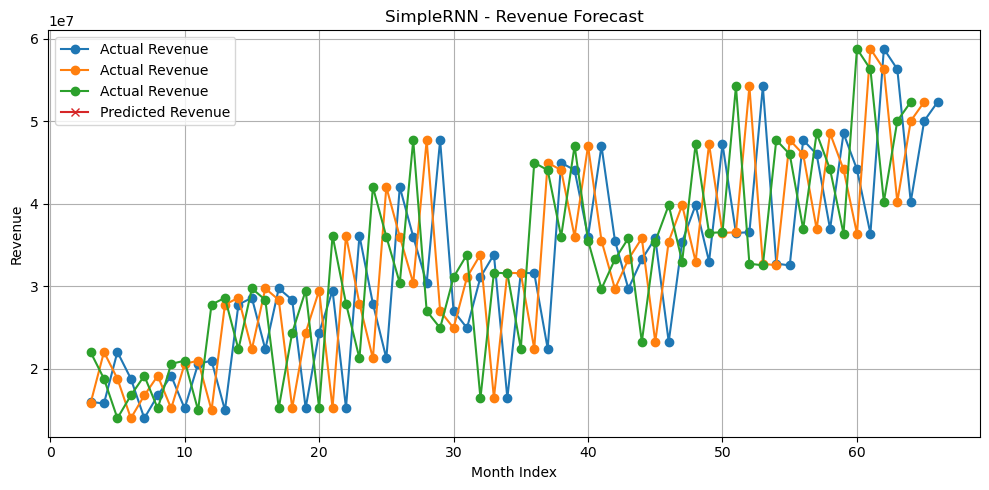

In [56]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(range(steop, len(df_rev)), y, label='Actual Revenue', marker='o')
plt.plot(range(steop, len(df_rev)), predicted.flatten(), label='Predicted Revenue', marker='x')
plt.title("SimpleRNN - Revenue Forecast")
plt.xlabel("Month Index")
plt.ylabel("Revenue")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()